# 다항회귀 (4/10)

1. x, y 그래서 데이터 분포 확인
2. 모델 적용, 선형회귀 적용
==> y는 예측값을 구해서 plot으로 추세선
3. RandomForestRegression 모델에 적용 후 시각화

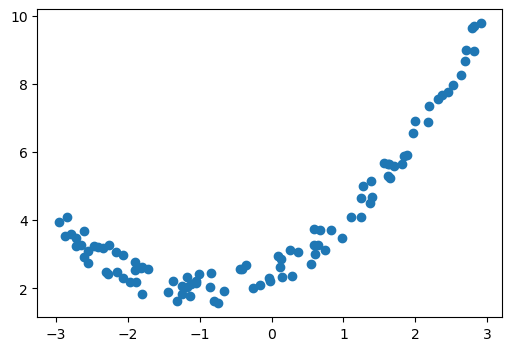

In [3]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

m = 100
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
plt.show()

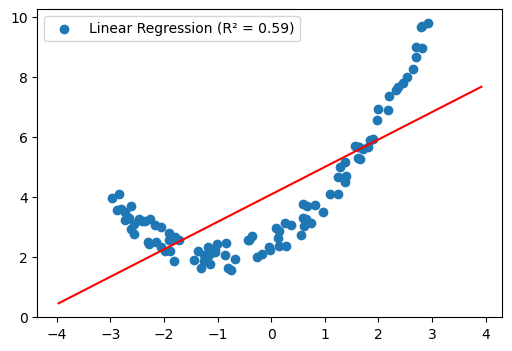

In [4]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x,y)

new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
y_pred = lin_reg.predict(new_x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')

plt.legend([f'Linear Regression (R² = {lin_reg.score(x,y):.2f})'])
plt.show()

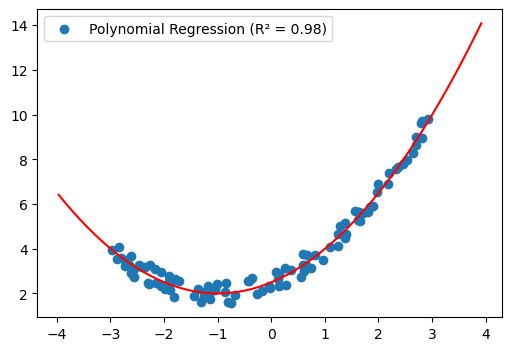

In [5]:
p_x = np.hstack([x**2, x])

lin_reg = LinearRegression()
lin_reg.fit(p_x,y)

y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')

plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

---

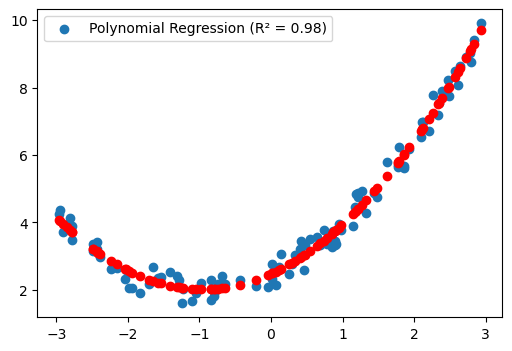

In [6]:
# # np.linspace(x.min()-1, x.max()+1, 100) : 수동으로 계산식 작성

# # poly_feature : 자동계산
from sklearn.preprocessing import PolynomialFeatures
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_x = poly_features.fit_transform(x)

lin_reg = LinearRegression()
lin_reg.fit(poly_x,y)   

y_pred = lin_reg.predict(poly_x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(poly_x,y):.2f})'])
plt.show()

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


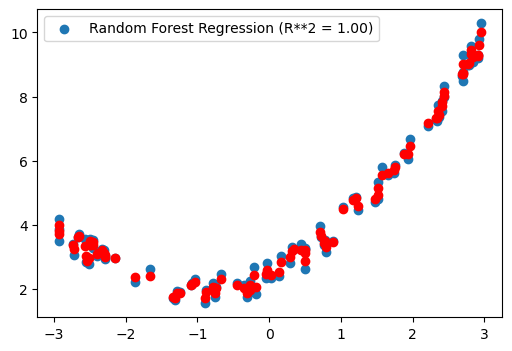

In [7]:
x = 6* np.random.rand(m,1) -3
y = 0.5*x**2 + x+2+np.random.rand(m,1)

from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)

forest_reg.fit(x,y)
y_predict = forest_reg.predict(x)

fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(x,y)
ax.scatter(x, y_predict, color = 'red')
plt.legend([f'Random Forest Regression (R**2 = {forest_reg.score(x,y):.2f})'])
plt.show()

# 확률적 경사하강법 모델

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


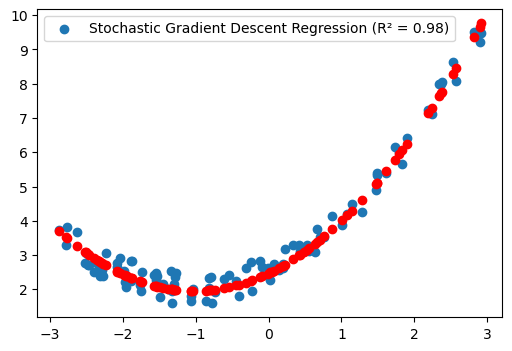

In [8]:
# 확률적 경사하강법 모델
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)
x_poly = poly.fit_transform(x)

sgd = SGDRegressor()
sgd.fit(x_poly, y)

y_pred = sgd.predict(x_poly)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Stochastic Gradient Descent Regression (R² = {sgd.score(x_poly, y):.2f})'])
plt.show()

In [9]:
# 과적합(과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플수 적게
n_samples = 20
# feature 수 많게  -> 과적합 유도
n_features = 100  # 컬럼수 또는 x의 수

x = np.random.randn(n_samples,n_features)
true_coef = np.zeros(n_features)  # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하게 설정  
true_coef[:5] = [10,-7,5,3,-2]  # 실제로 앞의 5개만 y에 영향을 줌  나머지 95개는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성  y = 10x1 + (-7x2) + 5x3 + ....
y = x @ true_coef + np.random.rand(n_samples)*5  # 정규분포 노이즈  , 표준편차 5 --> 큰 노이즈

# 일반선형회귀
from sklearn.model_selection import train_test_split
# 학습
# 결정계수.. score 학습용데이터, 테스트데이터
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)

lr.score(x_train,y_train),  lr.score(x_test, y_test)

(1.0, 0.3977376279359226)

In [10]:
# 모델이 노이즈까지 학습
# 계수가(가중치가) 비정상적으로 커짐
# 해결방안.. 규제(Regularization)
# Ridge(L2)
    #  loss = MSE + 알파*sum(가중치**2) --> 계수(가중치) 전체적으로작게 만듦, 모든 feature유지,안정적
    # 입력스케일에 민감하기때문에 표준화 필요
# Lasso(L1)
    #  loss = MSE + 알파*sum(|가중치|) --> 일부 계수(가중치)를 0으로 만들어 버림, 자동 feature selection

from sklearn.linear_model import Ridge
ridge = Ridge(alpha=30)
ridge.fit(x_train,y_train)
ridge.score(x_train,y_train), ridge.score(x_test,y_test)

(0.9432168631266318, 0.37901009934554386)

In [11]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=2)
lasso.fit(x_train,y_train)
lasso.score(x_train,y_train), lasso.score(x_test,y_test)

(0.9369715939308924, 0.5467446014495736)

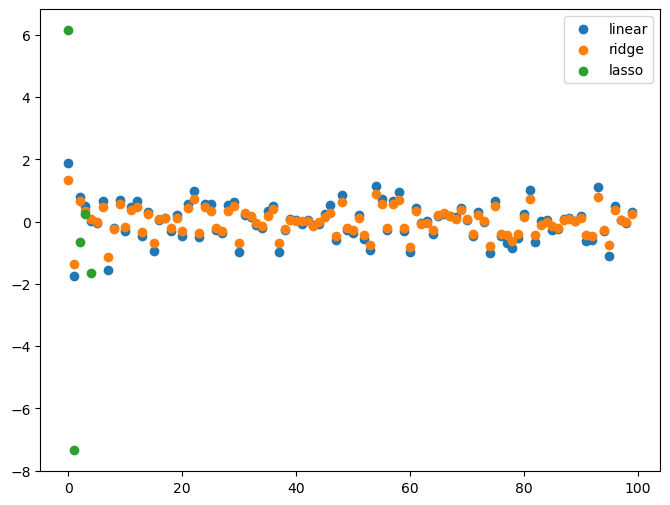

In [12]:
# 계수비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(lr.coef_[lr.coef_ != 0])), lr.coef_[lr.coef_ != 0], label='linear')
ax.scatter(np.arange(len(ridge.coef_[ridge.coef_ != 0])), ridge.coef_[ridge.coef_ != 0], label='ridge')
ax.scatter(np.arange(len(lasso.coef_[lasso.coef_ != 0])), lasso.coef_[lasso.coef_ != 0], label='lasso')
plt.legend()
plt.show()

# linear 계수폭팔(과적합)  Ridge  전체적으로 작아짐  Lasso  일부 계수는 0으로 만들어 버림

In [13]:
# 리지와 라쏘의 장점을 모두 갖춘 엘라스틱넷(ElasticNet)도 있음
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=1, l1_ratio=0.5)  # l1_ratio=0.5  Ridge와 Lasso의 비율

elastic_net.fit(x_train, y_train)

# ElasticNet의 R-squared(결정계수) 확인
elastic_net.score(x_train, y_train), elastic_net.score(x_test, y_test)

(0.9712641764300181, 0.38951324625346984)

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np

# 2차 방정식 데이터셋
np.random.seed(42)
m = 100
x = 6*np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)  # w1x1**2 + w2x2

x_train, y_train = x[ : m // 2],  y[ : m // 2 ,0]
x_valid, y_valid = x[m // 2 : ],  y[ m // 2 : ,0]

pipeline =  Pipeline([
    ('poly',PolynomialFeatures(degree=50,include_bias=False)),
    ('scale',StandardScaler())
])
x_train_prep = pipeline.fit_transform(x_train)
x_valid_prep = pipeline.transform(x_valid)
# 규제가 없고 학습률이 작은 모델
sgd_reg = SGDRegressor(penalty=None,random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_erros, val_erros = [],[]

from copy import deepcopy
from tqdm import tqdm
for epoch in tqdm(range(n_epochs)):
    sgd_reg.partial_fit(x_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(x_valid_prep)
    val_error =  np.sqrt(mean_squared_error(y_valid,y_valid_predict ))
    val_erros.append(val_error)
    
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(x_train_prep)
    train_erro = np.sqrt(mean_squared_error(y_train, y_train_predict))
    train_erros.append(train_erro)

100%|██████████| 500/500 [00:00<00:00, 1327.93it/s]


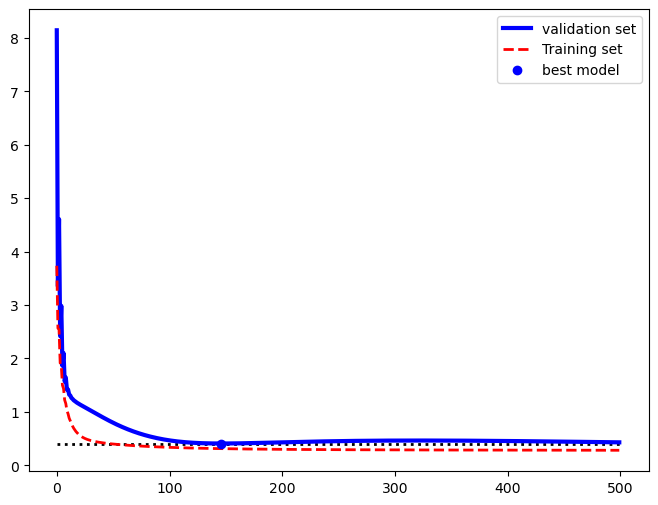

In [15]:
# 시각화
import matplotlib.pyplot as plt
best_epoch = np.argmin(val_erros)
fig,ax = plt.subplots(figsize=(8,6))
ax.plot([0,n_epochs], [best_valid_rmse,best_valid_rmse],'k:',linewidth=2)
ax.plot(val_erros,'b-',linewidth=3, label='validation set')
ax.plot(train_erros,'r--',linewidth=2, label='Training set')
ax.plot(best_epoch,best_valid_rmse, 'bo',label='best model')
plt.legend()

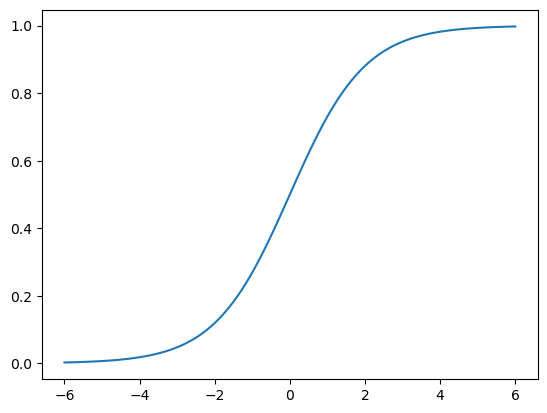

In [16]:
# 로지스틱회귀  -> 분류모델
import matplotlib.pylab as plt
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1+np.exp(-t))
plt.plot(t,sig)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
x, y = make_classification(
    n_samples=1000,
    n_features=20,
    # n_informative=  # 실제로 중요한 feature
    # n_redundant=  # informative 조합으로 만든 feature
    n_classes=2,
    random_state=42
)
y[:5]

array([1, 0, 1, 1, 0])

In [18]:
logistic = LogisticRegression()
logistic.fit(x,y)
y_pred = logistic.predict(x[:5])
print(y_pred)
y_pred_proba = logistic.predict_proba(x[:5])
print(y_pred_proba)

[1 0 1 1 0]
[[0.01698676 0.98301324]
 [0.8231496  0.1768504 ]
 [0.05614544 0.94385456]
 [0.12982649 0.87017351]
 [0.71744582 0.28255418]]
